In [1]:
# ======================================================
# Import core libraries for data processing, visualization,
# image handling, and deep learning model training
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
# ======================================================
# Load FER2013 dataset stored in parquet format.
# Inspect columns, preview data, and check dataset size.
# ======================================================

import pandas as pd

df = pd.read_parquet("/Users/bsama/Desktop/emotion recognition/0000.parquet")

print(df.columns)
print(df.head())
print(df.shape)

Index(['img_bytes', 'labels'], dtype='object')
                                           img_bytes  labels
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
(35887, 2)


In [3]:
# ======================================================
# Identify images that have missing or empty emotion labels.
# This helps ensure the dataset is fully labeled.
# ======================================================

LABEL_COL = "labels"

unlabelled = df[df[LABEL_COL].isna() | (df[LABEL_COL] == "")]
print("Unlabelled images:", len(unlabelled))
unlabelled.head()

Unlabelled images: 0


,img_bytes,labels


In [4]:
# ======================================================
# Examine how many samples belong to each emotion class.
# This helps detect dataset imbalance.
# ======================================================

df["labels"].value_counts().sort_index()

labels
0    4953
1     547
2    5121
3    8989
4    6198
5    6077
6    4002
Name: count, dtype: int64

In [5]:
# ======================================================
# Compute imbalance ratio = largest class / smallest class
# Higher values indicate stronger class imbalance.
# ======================================================

counts = df[LABEL_COL].value_counts()
print("Imbalance ratio:", counts.max()/counts.min())

Imbalance ratio: 16.43327239488117


In [6]:
# ======================================================
# Verify the datatype of image storage.
# FER2013 images are stored as raw byte arrays.
# ======================================================

type(df["img_bytes"][0])

bytes

In [7]:
# ======================================================
# Check dataset for corrupted images by attempting
# to open each image using PIL.
# ======================================================

from PIL import Image
import io

corrupt = 0

for img in df["img_bytes"].head(35887):  # check all sample
    try:
        Image.open(io.BytesIO(img)).verify()  # verify image integrity
    except:
        corrupt += 1

print("Corrupt images found:", corrupt)

Corrupt images found: 0


In [8]:
# ======================================================
# Identify duplicate rows in the dataset to check
# whether some images are repeated.
# ======================================================

duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 1793


In [9]:
df["labels"].isna().sum()

np.int64(0)

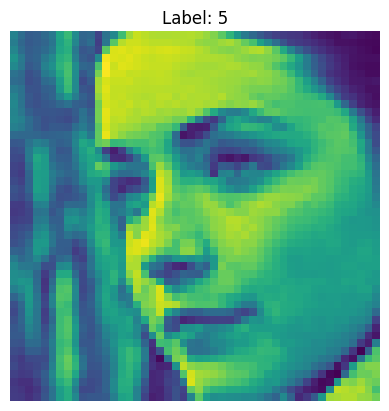

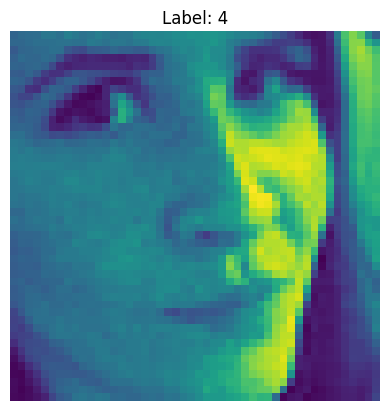

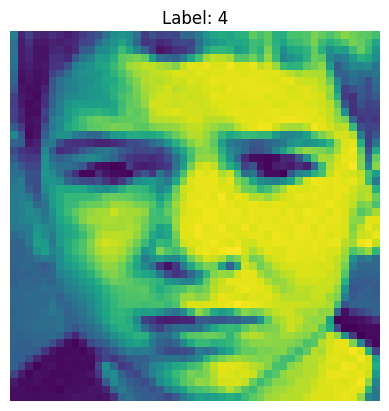

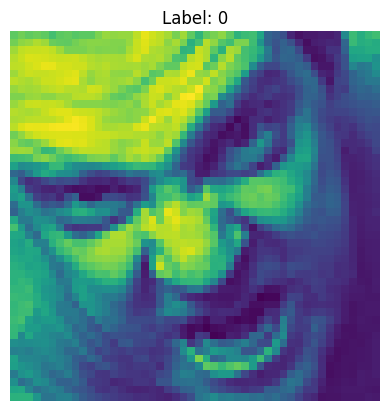

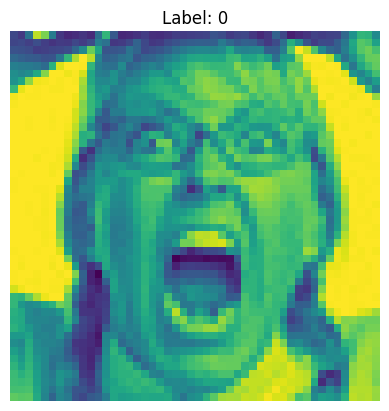

In [10]:
# ======================================================
# Randomly display a few images from the dataset
# along with their corresponding emotion labels.
# ======================================================

import matplotlib.pyplot as plt
import random
import io
from PIL import Image

for i in random.sample(range(len(df)), 5):
    img = Image.open(io.BytesIO(df["img_bytes"][i]))
    label = df["labels"][i]

    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

In [33]:
# ======================================================
# Use MTCNN face detector to filter images and keep
# only those where a face is successfully detected.
# Clean images are saved to a new directory.
# ======================================================

from mtcnn import MTCNN
import cv2
import os

detector = MTCNN()

input_folder = '/Users/bsama/Desktop/emotion recognition/balanced_train'
output_folder = '/Users/bsama/Desktop/emotion recognition/clean_balanced_train'
os.makedirs(output_folder, exist_ok=True)

for img_name in os.listdir(input_folder):
    path = os.path.join(input_folder, img_name)
    img = cv2.imread(path)

    if img is None:
        continue

    result = detector.detect_faces(img)

    if len(result) > 0:   # face detected
        cv2.imwrite(os.path.join(output_folder, img_name), img)

print("Done cleaning")

Done cleaning


In [5]:
# ======================================================
# Count the number of images per emotion category
# inside the cleaned test dataset directory.
# ======================================================

import os

dataset_path = '/Users/bsama/Desktop/emotion recognition/clean_balanced_test'

for emotion in os.listdir(dataset_path):
    emotion_path = os.path.join(dataset_path, emotion)

    if os.path.isdir(emotion_path):
        num_images = len([
            f for f in os.listdir(emotion_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        
        print(f"{emotion}: {num_images}")

happy: 1529
sad: 1285
fear: 1279
surprise: 1301
neutral: 1488
angry: 1291
disgust: 1114


In [3]:
# ======================================================
# Verify the number of images in each emotion folder
# of the balanced training dataset.
# ======================================================

import os

folder_path = '/Users/bsama/Desktop/Github emotion recognition /data/balanced/clean_balanced_train'

for subfolder in os.listdir(folder_path):
    subfolder_path = os.path.join(folder_path, subfolder)
    
    if os.path.isdir(subfolder_path):
        image_count = len([
            f for f in os.listdir(subfolder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        
        print(f"{subfolder}: {image_count} images")

clean_neutral: 6053 images
clean_happy: 6252 images
clean_sad: 4969 images
clean_fear: 5142 images
clean_disgust: 4502 images
clean_angry: 5400 images
clean_surprise: 5328 images
